In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import copy

from skimage.metrics import structural_similarity
from sklearn.metrics import mean_squared_error


(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

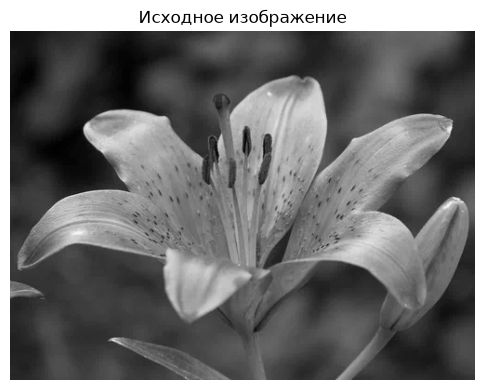

In [2]:
image = cv2.imread("PICT4039.jpg")

image_gray = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2GRAY
)


plt.figure(figsize=(6,6))
plt.imshow(image_gray, cmap="gray")
plt.title("Исходное изображение")
plt.axis("off")

(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

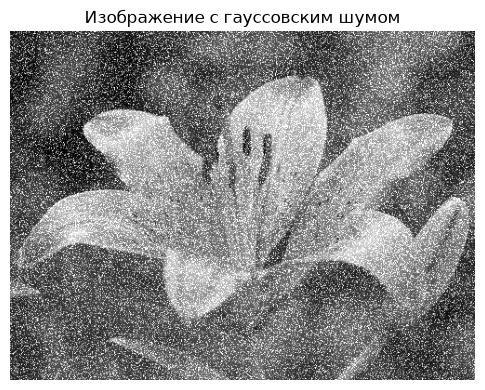

In [3]:
mean = 0
stddev = 100

noise_gauss = np.zeros(
    image_gray.shape,
    np.uint8
)

cv2.randn(
    noise_gauss,
    mean,
    stddev
)


image_noise_gauss = cv2.add(
    image_gray,
    noise_gauss
)


plt.figure(figsize=(6,6))
plt.imshow(
    image_noise_gauss,
    cmap="gray"
)

plt.title(
    "Изображение с гауссовским шумом"
)

plt.axis("off")

(np.float64(-0.5), np.float64(499.5), np.float64(374.5), np.float64(-0.5))

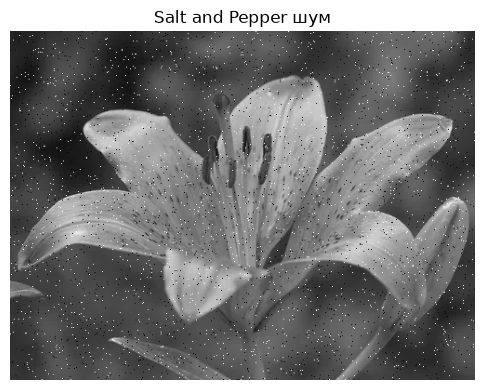

In [4]:
noise = np.random.randint(
    0,
    101,
    size=image_gray.shape
)


image_sp = copy.deepcopy(image_gray)


image_sp[
    np.where(noise == 0)
] = 0


image_sp[
    np.where(noise == 100)
] = 255


plt.figure(figsize=(6,6))

plt.imshow(
    image_sp,
    cmap="gray"
)

plt.title(
    "Salt and Pepper шум"
)

plt.axis("off")

Text(0.5, 1.0, 'Median 7')

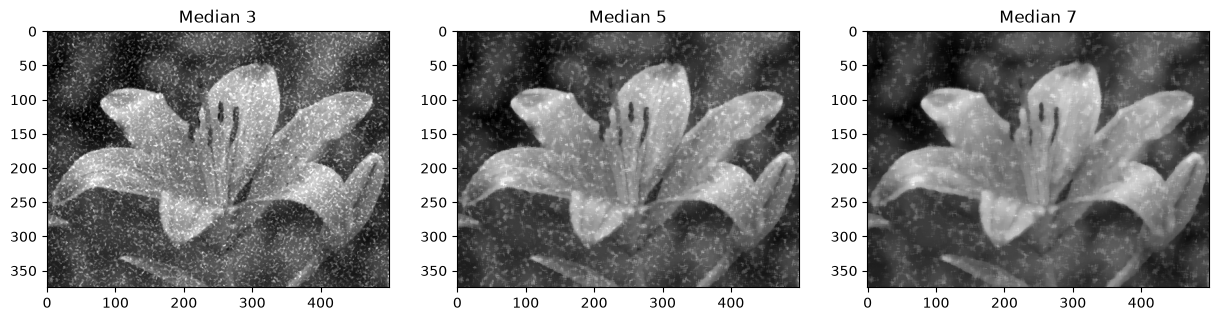

In [5]:
median_3 = cv2.medianBlur(
    image_noise_gauss,
    3
)

median_5 = cv2.medianBlur(
    image_noise_gauss,
    5
)

median_7 = cv2.medianBlur(
    image_noise_gauss,
    7
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(median_3,cmap="gray")
plt.title("Median 3")


plt.subplot(1,3,2)
plt.imshow(median_5,cmap="gray")
plt.title("Median 5")


plt.subplot(1,3,3)
plt.imshow(median_7,cmap="gray")
plt.title("Median 7")

Text(0.5, 1.0, 'Gaussian 7')

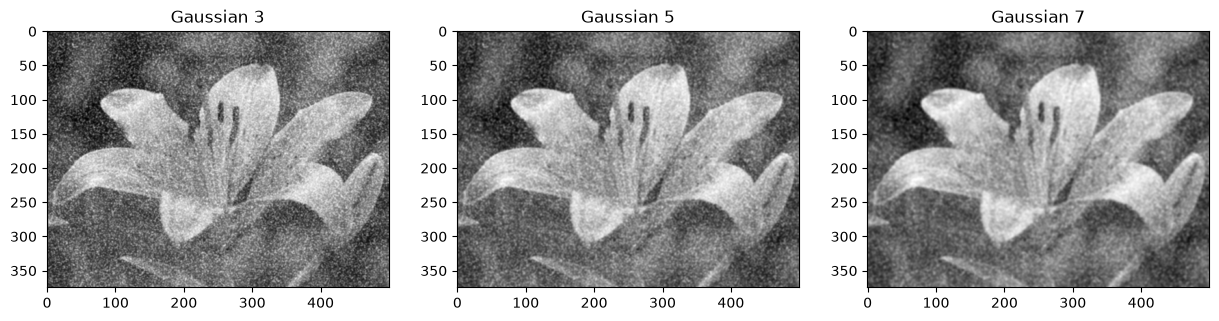

In [6]:
gauss_3 = cv2.GaussianBlur(
    image_noise_gauss,
    (3,3),
    0
)

gauss_5 = cv2.GaussianBlur(
    image_noise_gauss,
    (5,5),
    0
)

gauss_7 = cv2.GaussianBlur(
    image_noise_gauss,
    (7,7),
    0
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(gauss_3,cmap="gray")
plt.title("Gaussian 3")


plt.subplot(1,3,2)
plt.imshow(gauss_5,cmap="gray")
plt.title("Gaussian 5")


plt.subplot(1,3,3)
plt.imshow(gauss_7,cmap="gray")
plt.title("Gaussian 7")

Text(0.5, 1.0, 'Bilateral 3')

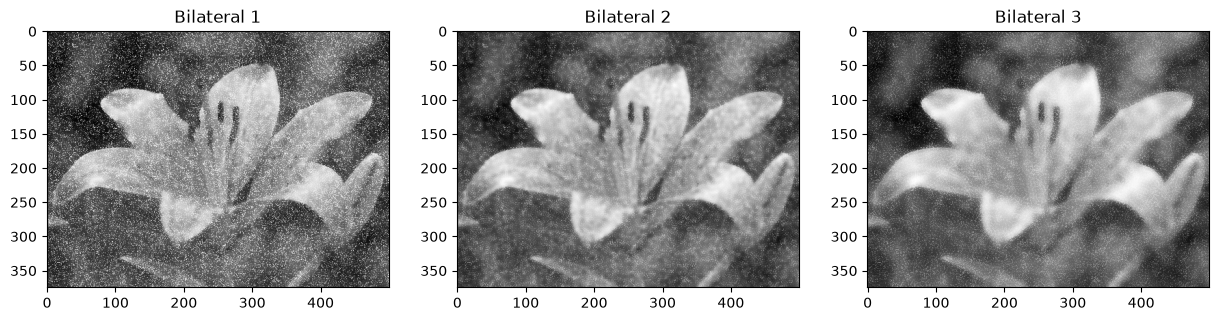

In [7]:
bilat_1 = cv2.bilateralFilter(
    image_noise_gauss,
    9,
    50,
    50
)


bilat_2 = cv2.bilateralFilter(
    image_noise_gauss,
    9,
    100,
    100
)


bilat_3 = cv2.bilateralFilter(
    image_noise_gauss,
    15,
    100,
    100
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(bilat_1,cmap="gray")
plt.title("Bilateral 1")


plt.subplot(1,3,2)
plt.imshow(bilat_2,cmap="gray")
plt.title("Bilateral 2")


plt.subplot(1,3,3)
plt.imshow(bilat_3,cmap="gray")
plt.title("Bilateral 3")

Text(0.5, 1.0, 'NLM h=30')

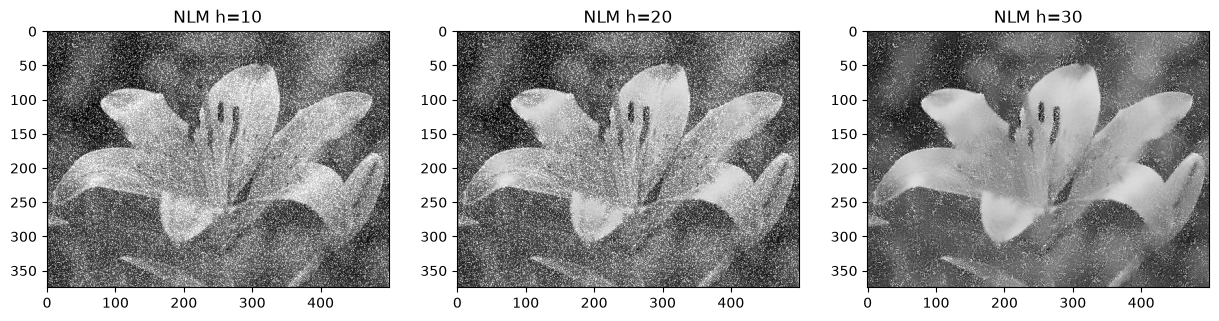

In [8]:
nlm_10 = cv2.fastNlMeansDenoising(
    image_noise_gauss,
    None,
    10
)


nlm_20 = cv2.fastNlMeansDenoising(
    image_noise_gauss,
    None,
    20
)


nlm_30 = cv2.fastNlMeansDenoising(
    image_noise_gauss,
    None,
    30
)


plt.figure(figsize=(15,5))


plt.subplot(1,3,1)
plt.imshow(nlm_10,cmap="gray")
plt.title("NLM h=10")


plt.subplot(1,3,2)
plt.imshow(nlm_20,cmap="gray")
plt.title("NLM h=20")


plt.subplot(1,3,3)
plt.imshow(nlm_30,cmap="gray")
plt.title("NLM h=30")

In [9]:
def compare(original, filtered):

    mse = mean_squared_error(
        original,
        filtered
    )


    ssim = structural_similarity(
        original,
        filtered
    )


    return mse, ssim

In [10]:
filters = {

"Median 3":median_3,
"Median 5":median_5,
"Median 7":median_7,

"Gaussian 3":gauss_3,
"Gaussian 5":gauss_5,
"Gaussian 7":gauss_7,

"Bilateral 1":bilat_1,
"Bilateral 2":bilat_2,
"Bilateral 3":bilat_3,

"NLM 10":nlm_10,
"NLM 20":nlm_20,
"NLM 30":nlm_30

}


for name,img in filters.items():

    mse,ssim = compare(
        image_gray,
        img
    )

    print(
        name,
        " MSE:",
        round(mse,2),
        " SSIM:",
        round(ssim,4)
    )

Median 3  MSE: 854.68  SSIM: 0.2636
Median 5  MSE: 408.4  SSIM: 0.4649
Median 7  MSE: 312.33  SSIM: 0.5947
Gaussian 3  MSE: 1673.64  SSIM: 0.301
Gaussian 5  MSE: 1520.15  SSIM: 0.4099
Gaussian 7  MSE: 1449.64  SSIM: 0.5266
Bilateral 1  MSE: 2232.85  SSIM: 0.1627
Bilateral 2  MSE: 1295.93  SSIM: 0.3737
Bilateral 3  MSE: 1284.21  SSIM: 0.3622
NLM 10  MSE: 3784.37  SSIM: 0.0922
NLM 20  MSE: 3687.5  SSIM: 0.117
NLM 30  MSE: 2151.64  SSIM: 0.2585
